In [233]:
from helper import produce_brut
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

#Analyse des data

In [234]:
axa = pd.read_csv("axa-output-1-to-71")
allianz = pd.read_csv("allianz-1-to-94")
camca = pd.read_csv("camca-output-1-to-49")
covea = pd.read_csv("covea-output-1-to-98")
l = [axa, allianz, camca, covea]

In [235]:
axa.columns

Index(['Unnamed: 0', 'num_page', 'text', 'width', 'height', 'area', 'chars',
       'char_size', 'pos_x', 'pos_y', 'aspect', 'layout', 'x0', 'x1', 'y0',
       'y1', 'assureur'],
      dtype='object')

Après avoir ouvert les csv dans un excel, et compris le fonctionnement de chaque features, je remarque que beaucoup de texte n'ont pas de sens, comme les N / A, les chiffres des tableau, et beaucoup de texte repétitif. J'ai jugé que commencer par traiter les données a ce moment ajoute beaucoup de bruit à l'analyse. J'ai commencé donc par éléminier les cas les plus flagrant. Le Layout permet de savoir si le texte est 'h' = horizontal ou 'v' = vertical. On peut donc par éliminer tout les lignes dont layout = 'v'

In [236]:
#1er filtre, on enleve les v
axa_filtre = axa.drop(axa[axa['layout'] == 'v'].index)

Dans cette exercice, l'importance est la récupération des titres et paragraphes. Or ces derniers n'apparaissent pas plus d’un certain nombre de fois. On choisit ici 10.

In [237]:
comptage = axa_filtre['text'].value_counts()

for valeur, occurrence in comptage.items():
    if occurrence ==2 :
        print(f"text : {valeur}, Occurrence : {occurrence}")

text : Frais de gestion financière , Occurrence : 2
text : 3 030 , Occurrence : 2
text : Résultat financier net , Occurrence : 2
text : E. GESTION DU CAPITAL , Occurrence : 2
text : Résultat net , Occurrence : 2
text : 29 , Occurrence : 2
text : Emprunts , Occurrence : 2
text : Provisions autres que les provisions techniques , Occurrence : 2
text : Chiffre d'affaires brut , Occurrence : 2
text : Résultat opérationnel hors résultat financier , Occurrence : 2
text : D.5 Autres informations , Occurrence : 2
text : 1273 , Occurrence : 2
text : ( En millions d'euros , sauf pourcentages ) , Occurrence : 2
text : Autres dettes , Occurrence : 2
text : 9 , Occurrence : 2
text : B.4 Système de contrôle interne , Occurrence : 2
text : 59 , Occurrence : 2
text : Actions détenues en auto - détention , Occurrence : 2
text : Dettes et dépôts des réassureurs , Occurrence : 2
text : 57 , Occurrence : 2
text : 36 , Occurrence : 2
text : 1 659 , Occurrence : 2
text : 344 , Occurrence : 2
text : Gains et 

In [238]:
occurance = axa_filtre['text'].value_counts()
axa_filtre= axa[axa['text'].isin(occurance[occurance < 10].index)]

On peut voir après que parmis les autres plus grande occurance il y a beaucoup de texte contenant des chiffres. On va donc filtrer tout les textes conenant que des chiffres qui seront ni des titres ni des paragraphes

In [239]:
indices_a_supprimer = pd.to_numeric(axa_filtre['text'], errors='coerce', downcast='integer').notna()
axa_filtre = axa_filtre.drop(axa_filtre[indices_a_supprimer].index)


Après ce filtre, je remarque que dans certaines csv, il reste encore des résidues, blocs de nombre de caractére < 5, qui sont des pourcentages des tableau, des chiffres qu'on a pas reussie à éliminer ou encore les numerotations des titres.

In [240]:
axa_filtre

,Unnamed: 0,num_page,text,width,height,area,chars,char_size,pos_x,pos_y,aspect,layout,x0,x1,y0,y1,assureur
0,0,1,AA,0.104202,0.035672,0.003717,3,0.001239,0.142857,0.115339,2.921121,h,0.090756,0.194958,0.097503,0.098692,axa-output-1-to-71
1,1,1,AXA SA,0.247059,0.035672,0.008813,7,0.001259,0.568908,0.366231,6.925887,h,0.445378,0.692437,0.348395,0.348395,axa-output-1-to-71
2,2,1,Rapport,0.213445,0.034483,0.007360,8,0.000920,0.415966,0.469084,6.189918,h,0.309244,0.522689,0.451843,0.451843,axa-output-1-to-71
3,3,1,sur la Solvabilité,0.443698,0.036861,0.016355,19,0.000861,0.452101,0.522592,12.037077,h,0.230252,0.673950,0.507729,0.504162,axa-output-1-to-71
4,4,1,et la Situation Financière,0.667227,0.030916,0.020628,27,0.000764,0.479832,0.585018,21.582243,h,0.146219,0.813445,0.569560,0.569560,axa-output-1-to-71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1930,1930,71,État S.19.01.21 Sinistres en Non - Vie,0.203361,0.008323,0.001693,39,0.000043,0.252941,0.488109,24.432486,h,0.151261,0.354622,0.483948,0.485137,axa-output-1-to-71
1931,1931,71,État S.22.01.21 Impact des mesures relatives a...,0.564706,0.008323,0.004700,101,0.000047,0.433613,0.510702,67.845171,h,0.151261,0.715966,0.506540,0.506540,axa-output-1-to-71
1932,1932,71,État S.23.01.02 Fonds propres,0.173109,0.010702,0.001853,30,0.000062,0.237815,0.532105,16.176016,h,0.151261,0.324370,0.526754,0.529132,axa-output-1-to-71
1933,1933,71,État S.25.01.01 Capital de solvabilité requis ...,0.490756,0.009513,0.004668,88,0.000053,0.396639,0.554102,51.590674,h,0.151261,0.642017,0.549346,0.549346,axa-output-1-to-71


In [241]:
axa_filtre = axa_filtre.loc[axa_filtre['chars'] > 5]

Après tout cela, les bases de donnée semblent plus pertinants que avant. On ecrit

In [242]:
def filtrer_dataframe(df):
    # Premier filtre: Supprimer les lignes où la valeur dans la colonne 'layout' est 'v'
    print(f"Avant le premier filtre : {len(df)} lignes")
    df = df[df['layout'] != 'v']
    print(f"Après le premier filtre : {len(df)} lignes")

    # Deuxième filtre: Enlever les redondances dans la colonne 'text'
    print(f"Avant le deuxième filtre : {len(df)} lignes")
    occurence_texte = df['text'].value_counts()
    df = df[df['text'].isin(occurence_texte[occurence_texte < 10].index)]
    print(f"Après le deuxième filtre : {len(df)} lignes")

    # Troisième filtre: Enlever les lignes contenant des chiffres dans la colonne 'text'
    print(f"Avant le troisième filtre : {len(df)} lignes")
    indices_a_supprimer = pd.to_numeric(df['text'], errors='coerce', downcast='integer').notna()
    df = df[~indices_a_supprimer]
    print(f"Après le troisième filtre : {len(df)} lignes")

    # Quatrième filtre: Conserver les lignes où la colonne 'chars' est supérieure à 5
    print(f"Avant le quatrième filtre : {len(df)} lignes")
    df = df[df['chars'] > 5]
    print(f"Après le quatrième filtre : {len(df)} lignes")

    return df


In [243]:
for k in l:
    print('######')
    filtrer_dataframe(k)

######
Avant le premier filtre : 1937 lignes
Après le premier filtre : 1912 lignes
Avant le deuxième filtre : 1912 lignes
Après le deuxième filtre : 1690 lignes
Avant le troisième filtre : 1690 lignes
Après le troisième filtre : 1347 lignes
Avant le quatrième filtre : 1347 lignes
Après le quatrième filtre : 1284 lignes
######
Avant le premier filtre : 4171 lignes
Après le premier filtre : 4091 lignes
Avant le deuxième filtre : 4091 lignes
Après le deuxième filtre : 3636 lignes
Avant le troisième filtre : 3636 lignes
Après le troisième filtre : 3426 lignes
Avant le quatrième filtre : 3426 lignes
Après le quatrième filtre : 2975 lignes
######
Avant le premier filtre : 2444 lignes
Après le premier filtre : 2127 lignes
Avant le deuxième filtre : 2127 lignes
Après le deuxième filtre : 1897 lignes
Avant le troisième filtre : 1897 lignes
Après le troisième filtre : 1744 lignes
Avant le quatrième filtre : 1744 lignes
Après le quatrième filtre : 1671 lignes
######
Avant le premier filtre : 4044

Je dessin l'histogramme de l'ensemble des nombres de caractère pour espèrer trouver un séparation entre les titres et les paragraphes. Cependant, il n'y a pas vraiment une séparation marquante

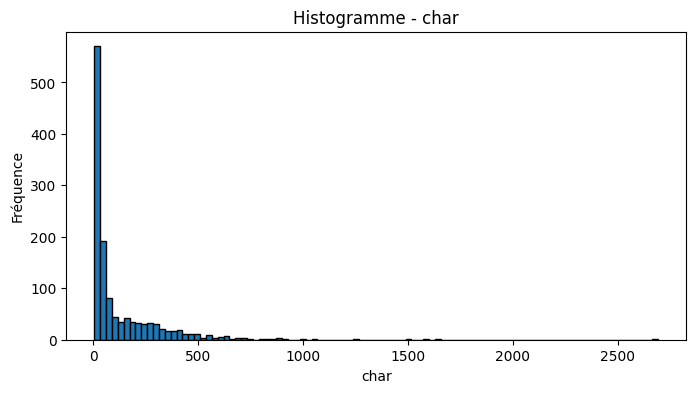

In [244]:
plt.figure(figsize=(8, 4))
plt.hist(axa_filtre['chars'],bins='auto', edgecolor='black')
plt.xlabel('char')
plt.ylabel('Fréquence')
plt.title('Histogramme - char')
plt.show()

Une séparation un peu plus marqué sur les colonnes area et sur char_size. Je voulais dans un premier temps faire la sépration de moi même avec des valeurs arbitraires. Puis je me suis rappelé que je suis un ingénieur en data-science ayant étudier des algorithmes de clustering.

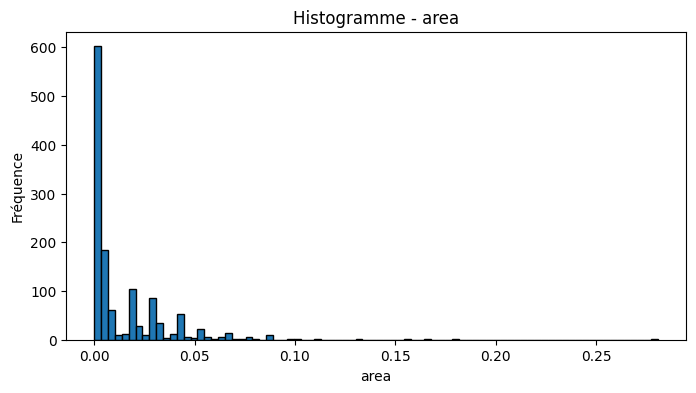

In [245]:
plt.figure(figsize=(8, 4))
plt.hist(axa_filtre['area'],bins='auto', edgecolor='black')
plt.xlabel('area')
plt.ylabel('Fréquence')
plt.title('Histogramme - area')
plt.show()

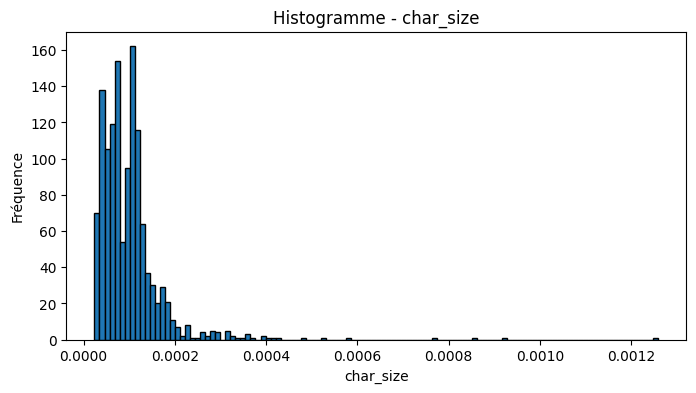

In [246]:
plt.figure(figsize=(8, 4))
plt.hist(axa_filtre['char_size'],bins='auto', edgecolor='black')
plt.xlabel('char_size')
plt.ylabel('Fréquence')
plt.title('Histogramme - char_size')
plt.show()

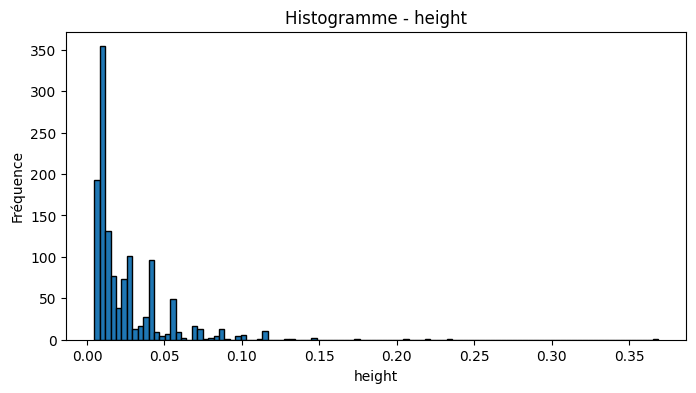

In [247]:
plt.figure(figsize=(8, 4))
plt.hist(axa_filtre['height'],bins='auto', edgecolor='black')
plt.xlabel('height')
plt.ylabel('Fréquence')
plt.title('Histogramme - height')
plt.show()

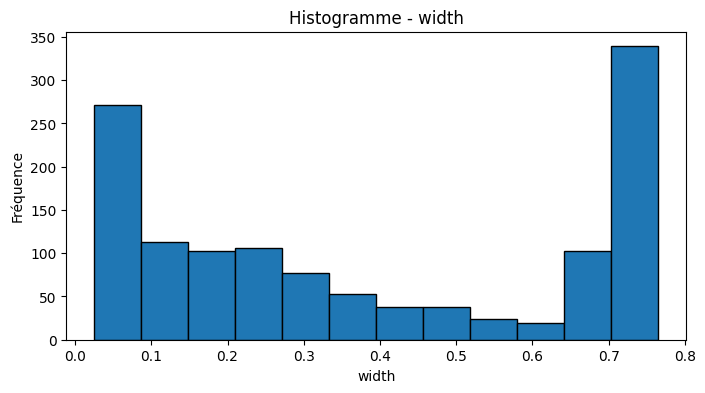

In [248]:
plt.figure(figsize=(8, 4))
plt.hist(axa_filtre['width'],bins='auto', edgecolor='black')
plt.xlabel('width')
plt.ylabel('Fréquence')
plt.title('Histogramme - width')
plt.show()

En regardant la fonction produce_brut, on peut voir que les textes sont justifiés donc les liste_x et y sont symétrique. x1 et x0 contiennent l'ensemble des informations de même pour y1 et y0. De plus, num_page et text ne permettent pas de faire des calcules, le cas des layout à été résolu plus tot. On a donc char_size, height et weight qui contiennent l'ensemble des informations disponible. On pourrai aussi faire une ACP et faire un clustering sur 2 dimensions. Cependant, je trouve que 3 dimensions est raisonnable pour faire un k-means. Cela facilite aussi l'interprétation.

C:\Users\Alain\AppData\Local\Temp\ipykernel_448\743953025.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[features] = scaler.fit_transform(df[features])


[1 1 1 ... 1 1 0]


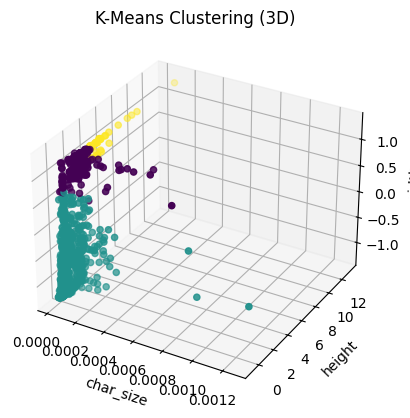

[[ 0.61522853  0.5515476   1.21699654]
 [-0.50345781 -0.47326151 -0.66612503]
 [ 3.46573701  3.47867516  1.26292445]]


C:\Users\Alain\AppData\Local\Temp\ipykernel_448\743953025.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[features] = scaler.inverse_transform(df[features])


In [249]:
df = axa_filtre

features = ['chars', 'height', 'width']

# Créer un objet StandardScaler
scaler = StandardScaler()

# Appliquer la normalisation aux données
df[features] = scaler.fit_transform(df[features])
x = df[features]

kmeans_model = KMeans(n_clusters=3, random_state=42)
labels = kmeans_model.fit_predict(x)
print(labels)
# Visualisation des clusters en 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Utiliser les étiquettes de cluster pour attribuer une couleur à chaque point
sc = ax.scatter(df['char_size'], df['height'], df['width'], c=labels, cmap='viridis')


ax.set_title('K-Means Clustering (3D)')
ax.set_xlabel('char_size')
ax.set_ylabel('height')
ax.set_zlabel('width')
plt.show()

df[features] = scaler.inverse_transform(df[features])
centroids = kmeans_model.cluster_centers_

print(centroids)

D'ici avec les centroids, nous pouvons repérer les caractéiristique de chaque cluster. On peut en déduire que le cluster ayant la plus grande taille (weight et height) est le cluster des paragraphes, puis celui des titres et enfin le reste des lignes inutiles

In [257]:
def k_means (df):
    features = ['chars', 'height', 'width']
    scaler = StandardScaler()

    # Appliquer la normalisation aux données
    df[features] = scaler.fit_transform(df[features])
    x = df[features]

    kmeans_model = KMeans(n_clusters=3)
    df['label'] = kmeans_model.fit_predict(x)
    centroids = kmeans_model.cluster_centers_
    ind = np.argsort((centroids[:,0]))
    cluster_labels = {ind[-1]: 'Paragraphe', ind[0]: 'Inutile', ind[1]: 'Titre',}
    df['label'] = df['label'].map(cluster_labels)

    df[features] = scaler.inverse_transform(df[features])
    return

In [258]:
k_means(axa_filtre)


C:\Users\Alain\AppData\Local\Temp\ipykernel_448\2833884213.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[features] = scaler.fit_transform(df[features])
C:\Users\Alain\AppData\Local\Temp\ipykernel_448\2833884213.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = kmeans_model.fit_predict(x)
C:\Users\Alain\AppData\Local\Temp\ipykernel_448\2833884213.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer]

In [259]:
axa_filtre

,Unnamed: 0,num_page,text,width,height,area,chars,char_size,pos_x,pos_y,aspect,layout,x0,x1,y0,y1,assureur,label
1,1,1,AXA SA,0.247059,0.035672,0.008813,7.0,0.001259,0.568908,0.366231,6.925887,h,0.445378,0.692437,0.348395,0.348395,axa-output-1-to-71,Inutile
2,2,1,Rapport,0.213445,0.034483,0.007360,8.0,0.000920,0.415966,0.469084,6.189918,h,0.309244,0.522689,0.451843,0.451843,axa-output-1-to-71,Inutile
3,3,1,sur la Solvabilité,0.443698,0.036861,0.016355,19.0,0.000861,0.452101,0.522592,12.037077,h,0.230252,0.673950,0.507729,0.504162,axa-output-1-to-71,Inutile
4,4,1,et la Situation Financière,0.667227,0.030916,0.020628,27.0,0.000764,0.479832,0.585018,21.582243,h,0.146219,0.813445,0.569560,0.569560,axa-output-1-to-71,Titre
6,6,1,AXA SA - SFCR 2022vf,0.168067,0.010701,0.001799,21.0,0.000086,0.885714,0.903092,15.705013,h,0.801681,0.969748,0.897741,0.898930,axa-output-1-to-71,Inutile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1930,1930,71,État S.19.01.21 Sinistres en Non - Vie,0.203361,0.008323,0.001693,39.0,0.000043,0.252941,0.488109,24.432486,h,0.151261,0.354622,0.483948,0.485137,axa-output-1-to-71,Inutile
1931,1931,71,État S.22.01.21 Impact des mesures relatives a...,0.564706,0.008323,0.004700,101.0,0.000047,0.433613,0.510702,67.845171,h,0.151261,0.715966,0.506540,0.506540,axa-output-1-to-71,Inutile
1932,1932,71,État S.23.01.02 Fonds propres,0.173109,0.010702,0.001853,30.0,0.000062,0.237815,0.532105,16.176016,h,0.151261,0.324370,0.526754,0.529132,axa-output-1-to-71,Inutile
1933,1933,71,État S.25.01.01 Capital de solvabilité requis ...,0.490756,0.009512,0.004668,88.0,0.000053,0.396639,0.554102,51.590674,h,0.151261,0.642017,0.549346,0.549346,axa-output-1-to-71,Inutile


À partir de ce moment, il suffit juste de faire une fonction générale qui d'abord applique le filtre pour avec un dataset plus propre, puis fait le k-means sur le dataset, le labélise, puis merge pour que le dataset d'origine récupère les labels et complète les lignes de label vides avec inutile filtré pour cette raison.

In [264]:
def labeliseur (df):
    df_copie = df.copy()
    df_copie = filtrer_dataframe(df_copie)
    k_means(df_copie)
    df = pd.merge(df, df_copie[['Unnamed: 0', 'label']], on='Unnamed: 0', how='left')
    df['label'] = df['label'].fillna('Inutile')
    return df

En parallèle du k-means, j’ai aussi essayé d'autres méthodes comme le DBSCAN. Cependant, je n’ai pas réussi à obtenir 3 clusters. De plus, l'interprétation des clusters est différente du k-means. Au final, la fonction labeliseur permet de labelliser l'ensemble du dataset, sans une précision du 100% mais fait une grande partie du travail.